<a href="https://colab.research.google.com/github/azizeke/Aziz_Azure_VM/blob/main/Module5_BigData_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# PySpark Kurulumu
!pip install pyspark findspark -q

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonSalesAnalysis") \
    .getOrCreate()

print("✅ Spark başarıyla başlatıldı!")
print(f"Spark versiyonu: {spark.version}")

✅ Spark başarıyla başlatıldı!
Spark versiyonu: 4.0.2


In [4]:
# CSV dosyasını yüklemek için
from google.colab import files
uploaded = files.upload()

Saving Amazon Sale Report.csv to Amazon Sale Report.csv


In [5]:
# CSV dosyasını Spark ile okuma
df = spark.read.csv("Amazon Sale Report.csv",
                     header=True,
                     inferSchema=True)

print("✅ Veri başarıyla yüklendi!")
print(f"Satır sayısı: {df.count()}")
print(f"Sütun sayısı: {len(df.columns)}")
print("\nSütun isimleri:")
print(df.columns)

✅ Veri başarıyla yüklendi!
Satır sayısı: 128975
Sütun sayısı: 24

Sütun isimleri:
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


In [6]:
# ============================================
# BÖLÜM 1 — Büyük Veri Nedir? (3V Analizi)
# ============================================

from pyspark.sql.functions import col, to_date, count

# --- HACİM (Volume) ---
print("=" * 50)
print("📦 HACİM (VOLUME) ANALİZİ")
print("=" * 50)
print(f"Toplam Satır Sayısı : {df.count()}")
print(f"Toplam Sütun Sayısı : {len(df.columns)}")

# --- ÇEŞİTLİLİK (Variety) ---
print("\n" + "=" * 50)
print("🔀 ÇEŞİTLİLİK (VARIETY) ANALİZİ")
print("=" * 50)
print("Sütun adları ve veri tipleri:")
df.printSchema()

# --- HIZ (Velocity) ---
print("=" * 50)
print("⚡ HIZ (VELOCITY) ANALİZİ — Tarihe Göre Sipariş Sayısı")
print("=" * 50)
df_date = df.groupBy("Date").count().orderBy("Date")
df_date.show(10)

📦 HACİM (VOLUME) ANALİZİ
Toplam Satır Sayısı : 128975
Toplam Sütun Sayısı : 24

🔀 ÇEŞİTLİLİK (VARIETY) ANALİZİ
Sütun adları ve veri tipleri:
root
 |-- index: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Fulfilment: string (nullable = true)
 |-- Sales Channel : string (nullable = true)
 |-- ship-service-level: string (nullable = true)
 |-- Style: string (nullable = true)
 |-- SKU: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- ASIN: string (nullable = true)
 |-- Courier Status: string (nullable = true)
 |-- Qty: integer (nullable = true)
 |-- currency: string (nullable = true)
 |-- Amount: double (nullable = true)
 |-- ship-city: string (nullable = true)
 |-- ship-state: string (nullable = true)
 |-- ship-postal-code: double (nullable = true)
 |-- ship-country: string (nullable = true)
 |-- promotion-ids: string (nullable = true)


📘 BÖLÜM 1 — YORUM

HACİM (Volume):
Veri seti 128.975 satır ve 24 sütundan oluşmaktadır.
Bu büyük veri kavramının "Hacim" boyutunu temsil eder.

ÇEŞİTLİLİK (Variety):
Veri setinde string, integer gibi farklı veri tipleri mevcuttur.
Metin (Category, Status), sayısal (Qty, Amount) ve tarih (Date)
verileri bir arada bulunmaktadır.

HIZ (Velocity):
Tarih sütunu günlük sipariş akışını göstermektedir.
Her gün yüzlerce sipariş oluşmakta, bu da verinin sürekli
ve hızlı üretildiğini göstermektedir.

In [7]:
# ============================================
# BÖLÜM 2 — Hadoop & MapReduce Simülasyonu
# ============================================

from pyspark.sql.functions import sum, col

print("=" * 50)
print("🐘 MAPREDUCE SİMÜLASYONU")
print("=" * 50)

# MAP aşaması — her satırdan (Category, Amount) çıkar
# REDUCE aşaması — kategoriye göre toplam satışı hesapla

df_mapreduce = df.groupBy("Category") \
                 .agg(sum("Amount").alias("Toplam_Satis")) \
                 .orderBy("Toplam_Satis", ascending=False)

print("Kategoriye Göre Toplam Satışlar:")
df_mapreduce.show(20)

🐘 MAPREDUCE SİMÜLASYONU
Kategoriye Göre Toplam Satışlar:
+-------------+--------------------+
|     Category|        Toplam_Satis|
+-------------+--------------------+
|          Set| 3.920412402999991E7|
|        kurta|2.1299546699999988E7|
|Western Dress| 1.121607269000002E7|
|          Top|           5347792.3|
| Ethnic Dress|   791217.6599999999|
|       Blouse|           458408.18|
|       Bottom|  150667.97999999998|
|        Saree|           123933.76|
|      Dupatta|               915.0|
+-------------+--------------------+



📘 BÖLÜM 2 — YORUM

HDFS: Büyük veriyi birden fazla makineye dağıtarak depolayan
dosya sistemidir. Veri parçalara bölünür ve farklı node'lara
dağıtılır. Bir node çökse bile veri kaybolmaz.

MapReduce: Büyük veriyi paralel işlemek için kullanılan modeldir.
- MAP aşaması: Her satırdan (Category, Amount) bilgisi çıkarıldı
- REDUCE aşaması: Aynı kategoriler gruplandı, tutarlar toplandı

Sonuç: Set kategorisi ~39.2M ile en yüksek satışa sahiptir.

In [8]:
# ============================================
# BÖLÜM 3 — RDD vs DataFrame Karşılaştırması
# ============================================

import time

print("=" * 50)
print("📌 RDD ile Kategoriye Göre Toplam Satışlar")
print("=" * 50)

# RDD yöntemi
start_rdd = time.time()

rdd = df.rdd.map(lambda row: (row["Category"], row["Amount"] or 0)) \
            .reduceByKey(lambda a, b: a + b) \
            .sortBy(lambda x: x[1], ascending=False)

rdd_result = rdd.collect()
end_rdd = time.time()

for item in rdd_result[:5]:
    print(f"{item[0]}: {item[1]:.2f}")

print(f"\n⏱️ RDD süresi: {end_rdd - start_rdd:.2f} saniye")

print("\n" + "=" * 50)
print("📌 DataFrame ile Kategoriye Göre Toplam Satışlar")
print("=" * 50)

# DataFrame yöntemi
from pyspark.sql.functions import sum

start_df = time.time()

df_result = df.groupBy("Category") \
              .agg(sum("Amount").alias("Toplam_Satis")) \
              .orderBy("Toplam_Satis", ascending=False)

df_result.show(5)
end_df = time.time()

print(f"⏱️ DataFrame süresi: {end_df - start_df:.2f} saniye")

# Cache ile optimizasyon
print("\n" + "=" * 50)
print("🚀 Cache ile Optimizasyon")
print("=" * 50)
df.cache()
start_cache = time.time()
df.groupBy("Category").agg(sum("Amount")).collect()
end_cache = time.time()
print(f"⏱️ Cache sonrası süre: {end_cache - start_cache:.2f} saniye")

📌 RDD ile Kategoriye Göre Toplam Satışlar
Set: 39204124.03
kurta: 21299546.70
Western Dress: 11216072.69
Top: 5347792.30
Ethnic Dress: 791217.66

⏱️ RDD süresi: 10.67 saniye

📌 DataFrame ile Kategoriye Göre Toplam Satışlar
+-------------+--------------------+
|     Category|        Toplam_Satis|
+-------------+--------------------+
|          Set| 3.920412402999991E7|
|        kurta|2.1299546699999988E7|
|Western Dress| 1.121607269000002E7|
|          Top|           5347792.3|
| Ethnic Dress|   791217.6599999999|
+-------------+--------------------+
only showing top 5 rows
⏱️ DataFrame süresi: 1.14 saniye

🚀 Cache ile Optimizasyon
⏱️ Cache sonrası süre: 4.57 saniye


📘 BÖLÜM 3 — YORUM

RDD vs DataFrame Karşılaştırması:

RDD (10.67 sn): Düşük seviyeli API'dir. Her işlemi manuel
yazmak gerekir, optimizasyon yoktur, daha yavaştır.

DataFrame (1.14 sn): Yüksek seviyeli API'dir. Spark'ın
Catalyst optimizer'ı otomatik optimizasyon yapar, ~9x daha hızlıdır.

Cache (4.57 sn): Veriyi bellekte tutar. İlk seferinde yavaş
olabilir ancak tekrarlayan sorgularda çok daha hızlıdır.

Sonuç: DataFrame daha okunaklı ve performanslıdır.
Büyük veri projelerinde DataFrame tercih edilmelidir.

In [9]:
# ============================================
# BÖLÜM 4 — Spark SQL
# ============================================

from pyspark.sql.functions import count, sum, round

# Geçici tablo oluştur
df.createOrReplaceTempView("amazon_sales")

print("=" * 50)
print("📊 1. Her Kategori için Toplam Satış Tutarı")
print("=" * 50)
spark.sql("""
    SELECT Category,
           ROUND(SUM(Amount), 2) as Toplam_Satis
    FROM amazon_sales
    GROUP BY Category
    ORDER BY Toplam_Satis DESC
""").show()

print("=" * 50)
print("📊 2. En Yüksek Satışlara Sahip Eyalet")
print("=" * 50)
spark.sql("""
    SELECT `ship-state`,
           ROUND(SUM(Amount), 2) as Toplam_Satis
    FROM amazon_sales
    GROUP BY `ship-state`
    ORDER BY Toplam_Satis DESC
    LIMIT 10
""").show()

print("=" * 50)
print("📊 3. İptal Edilmiş Siparişlerin Oranı")
print("=" * 50)
spark.sql("""
    SELECT
        COUNT(*) as Toplam_Siparis,
        SUM(CASE WHEN Status = 'Cancelled' THEN 1 ELSE 0 END) as Iptal_Sayisi,
        ROUND(SUM(CASE WHEN Status = 'Cancelled' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Iptal_Orani
    FROM amazon_sales
""").show()

📊 1. Her Kategori için Toplam Satış Tutarı
+-------------+-------------+
|     Category| Toplam_Satis|
+-------------+-------------+
|          Set|3.920412403E7|
|        kurta| 2.12995467E7|
|Western Dress|1.121607269E7|
|          Top|    5347792.3|
| Ethnic Dress|    791217.66|
|       Blouse|    458408.18|
|       Bottom|    150667.98|
|        Saree|    123933.76|
|      Dupatta|        915.0|
+-------------+-------------+

📊 2. En Yüksek Satışlara Sahip Eyalet
+--------------+-------------+
|    ship-state| Toplam_Satis|
+--------------+-------------+
|   MAHARASHTRA|1.333553414E7|
|     KARNATAKA|1.048111437E7|
|     TELANGANA|   6916615.65|
| UTTAR PRADESH|   6816642.08|
|    TAMIL NADU|   6515650.11|
|         DELHI|   4235215.97|
|        KERALA|   3830227.58|
|   WEST BENGAL|   3507880.44|
|ANDHRA PRADESH|   3219831.72|
|       HARYANA|   2882092.99|
+--------------+-------------+

📊 3. İptal Edilmiş Siparişlerin Oranı
+--------------+------------+-----------+
|Toplam_Sipar

In [10]:
# ============================================
# BÖLÜM 4 — Spark Streaming Simülasyonu
# ============================================

import os
import shutil
from pyspark.sql.functions import sum

# Klasör oluştur
os.makedirs("streaming_input", exist_ok=True)

# Mevcut verinin bir kısmını streaming klasörüne yaz
df.limit(1000).toPandas().to_csv("streaming_input/batch1.csv", index=False)

print("✅ Streaming klasörü oluşturuldu!")
print("📂 streaming_input/batch1.csv yazıldı")

# Streaming okuma
stream_df = spark.readStream \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("streaming_input/")

# Kategori bazında toplam satış
query = stream_df.groupBy("Category") \
    .agg(sum("Amount").alias("Toplam_Satis")) \
    .writeStream \
    .outputMode("complete") \
    .format("console") \
    .trigger(once=True) \
    .start()

query.awaitTermination(30)
print("✅ Streaming tamamlandı!")

✅ Streaming klasörü oluşturuldu!
📂 streaming_input/batch1.csv yazıldı


IllegalArgumentException: Schema must be specified when creating a streaming source DataFrame. If some files already exist in the directory, then depending on the file format you may be able to create a static DataFrame on that directory with 'spark.read.load(directory)' and infer schema from it.

In [13]:

# ============================================
# BÖLÜM 4 — Spark Streaming Simülasyonu (Düzeltilmiş)
# ============================================


from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
from pyspark.sql.functions import sum as spark_sum

schema = StructType([
    StructField("index", IntegerType(), True),
    StructField("Order ID", StringType(), True),
    StructField("Date", StringType(), True),
    StructField("Status", StringType(), True),
    StructField("Fulfilment", StringType(), True),
    StructField("Sales Channel ", StringType(), True),
    StructField("ship-service-level", StringType(), True),
    StructField("Style", StringType(), True),
    StructField("SKU", StringType(), True),
    StructField("Category", StringType(), True),
    StructField("Size", StringType(), True),
    StructField("ASIN", StringType(), True),
    StructField("Courier Status", StringType(), True),
    StructField("Qty", IntegerType(), True),
    StructField("currency", StringType(), True),
    StructField("Amount", DoubleType(), True),
    StructField("ship-city", StringType(), True),
    StructField("ship-state", StringType(), True),
    StructField("ship-postal-code", StringType(), True),
    StructField("ship-country", StringType(), True),
    StructField("promotion-ids", StringType(), True),
    StructField("B2B", StringType(), True),
    StructField("fulfilled-by", StringType(), True),
    StructField("Unnamed: 22", StringType(), True),
])

stream_df = spark.readStream.schema(schema).option("header", "true").csv("streaming_input/")

query = stream_df.groupBy("Category").agg(spark_sum("Amount").alias("Toplam_Satis")).writeStream.outputMode("complete").format("console").trigger(once=True).start()

query.awaitTermination(30)
print("Streaming tamamlandi!")

Streaming tamamlandi!


📘 BÖLÜM 4 — YORUM

Spark SQL:
- createOrReplaceTempView ile DataFrame'i SQL tablosuna dönüştürdük
- En yüksek satış: Set kategorisi (~39.2M)
- En yüksek eyalet: Maharashtra (~13.3M)
- İptal oranı: %14.21 (18.332 sipariş iptal edilmiş)

Spark Streaming:
- Gerçek zamanlı veri işleme simülasyonu yaptık
- Yeni dosya geldiğinde otomatik olarak kategori bazında
  toplam satışlar hesaplandı
- Gerçek hayatta: log verileri, sensör verileri, finansal
  işlemler anlık olarak bu şekilde işlenir

In [15]:
# ============================================
# BÖLÜM 5 — Dağıtılmış Depolama
# ============================================

print("=" * 50)
print("💾 1. Parquet Formatında Kaydetme")
print("=" * 50)

df.write.mode("overwrite").parquet("output/amazon_sales_parquet")
print("✅ Parquet olarak kaydedildi!")

# Parquet'i tekrar oku
df_parquet = spark.read.parquet("output/amazon_sales_parquet")
print(f"Parquet satır sayısı: {df_parquet.count()}")

print("\n" + "=" * 50)
print("💾 2. JSON Formatında Kaydetme")
print("=" * 50)

df.write.mode("overwrite").json("output/amazon_sales_json")
print("✅ JSON olarak kaydedildi!")

# JSON'ı tekrar oku
df_json = spark.read.json("output/amazon_sales_json")
print(f"JSON satır sayısı: {df_json.count()}")

print("\n" + "=" * 50)
print("📊 Parquet vs JSON Karşılaştırması")
print("=" * 50)

# Dosya boyutu karşılaştırması (düzeltilmiş)
import os

parquet_size = 0
for f in os.listdir("output/amazon_sales_parquet"):
    if f.endswith(".parquet"):
        parquet_size += os.path.getsize("output/amazon_sales_parquet/" + f)

json_size = 0
for f in os.listdir("output/amazon_sales_json"):
    if f.endswith(".json"):
        json_size += os.path.getsize("output/amazon_sales_json/" + f)

print(f"Parquet boyutu : {parquet_size / 1024 / 1024:.2f} MB")
print(f"JSON boyutu    : {json_size / 1024 / 1024:.2f} MB")
print(f"Parquet, JSON'dan {json_size/parquet_size:.1f}x daha küçük!")

💾 1. Parquet Formatında Kaydetme
✅ Parquet olarak kaydedildi!
Parquet satır sayısı: 128975

💾 2. JSON Formatında Kaydetme
✅ JSON olarak kaydedildi!
JSON satır sayısı: 128975

📊 Parquet vs JSON Karşılaştırması
Parquet boyutu : 6.25 MB
JSON boyutu    : 101.09 MB
Parquet, JSON'dan 16.2x daha küçük!


📘 BÖLÜM 5 — YORUM

Parquet Formatının Avantajları:
- Sütun bazlı depolama yapar, sadece gerekli sütunlar okunur
- Güçlü sıkıştırma: JSON'dan 16.2x daha küçük (101MB → 6.25MB)
- Büyük veri sorgularında çok daha hızlıdır
- Veri tiplerini korur, schema bilgisini içinde saklar

HDFS ve S3 Neden Önemlidir?
- HDFS: Veriyi birden fazla makineye dağıtır, hata toleransı sağlar
- S3: Bulut tabanlı, sınırsız ölçeklenebilir depolama sunar
- Her ikisi de petabayt ölçeğinde veriyi güvenle saklayabilir
- Tek bir disk yerine dağıtık sistemde saklama = veri kaybı yok

In [16]:
# ============================================
# BÖLÜM 6 — Filtreleme, Gruplama, Join
# ============================================

from pyspark.sql.functions import sum, avg, round, col

print("=" * 50)
print("🔍 1. Filtreleme — Tutarı 1000'den Yüksek Siparişler")
print("=" * 50)
df_filtered = df.filter(col("Amount") > 1000)
print(f"1000'den yüksek sipariş sayısı: {df_filtered.count()}")
df_filtered.select("Order ID", "Category", "Amount", "ship-state").show(10)

print("=" * 50)
print("📊 2. Gruplama — Eyaletlere Göre Toplam Satışlar")
print("=" * 50)
df_state = df.groupBy("ship-state") \
             .agg(round(sum("Amount"), 2).alias("Toplam_Satis")) \
             .orderBy("Toplam_Satis", ascending=False)
df_state.show(10)

print("=" * 50)
print("🔗 3. Join — Kategori Bilgileri ile Birleştirme")
print("=" * 50)

# İkinci DataFrame oluştur (kategori bilgileri)
from pyspark.sql import Row
category_info = spark.createDataFrame([
    Row(Category="Set", Tip="Kombin", Hedef_Kitle="Kadin"),
    Row(Category="kurta", Tip="Giysi", Hedef_Kitle="Kadin"),
    Row(Category="Western Dress", Tip="Elbise", Hedef_Kitle="Kadin"),
    Row(Category="Top", Tip="Ust Giyim", Hedef_Kitle="Kadin"),
    Row(Category="Ethnic Dress", Tip="Geleneksel", Hedef_Kitle="Kadin"),
    Row(Category="Blouse", Tip="Bluz", Hedef_Kitle="Kadin"),
    Row(Category="Bottom", Tip="Alt Giyim", Hedef_Kitle="Kadin"),
    Row(Category="Saree", Tip="Geleneksel", Hedef_Kitle="Kadin"),
    Row(Category="Dupatta", Tip="Aksesuar", Hedef_Kitle="Kadin"),
])

df_joined = df.join(category_info, on="Category", how="left")
df_joined.select("Category", "Tip", "Hedef_Kitle", "Amount").show(10)

print("=" * 50)
print("📋 4. Pivot Tablo — Eyalet x Kategori")
print("=" * 50)
df_pivot = df.groupBy("ship-state") \
             .pivot("Category") \
             .agg(round(sum("Amount"), 2)) \
             .orderBy("ship-state")
df_pivot.show(5)

🔍 1. Filtreleme — Tutarı 1000'den Yüksek Siparişler
1000'den yüksek sipariş sayısı: 13332
+-------------------+--------+-------+--------------+
|           Order ID|Category| Amount|    ship-state|
+-------------------+--------+-------+--------------+
|404-9632124-1107550|     Set| 1233.0|ANDHRA PRADESH|
|408-3478480-0881162|     Set| 1126.0| UTTAR PRADESH|
|408-3917043-5314763|     Set| 1146.0|ANDHRA PRADESH|
|408-7138000-9728362|     Set| 1033.0|      NAGALAND|
|405-6480932-8759528|     Set| 1146.0|     KARNATAKA|
|408-4069830-3819562|     Set| 1281.0|   WEST BENGAL|
|408-4069830-3819562|     Set| 1186.0|   WEST BENGAL|
|404-6522553-9345930|     Set|1105.36|   UTTARAKHAND|
|408-7698765-2294756|     Set| 1338.0|   MAHARASHTRA|
|406-0715107-8168308|     Set| 1186.0|   UTTARAKHAND|
+-------------------+--------+-------+--------------+
only showing top 10 rows
📊 2. Gruplama — Eyaletlere Göre Toplam Satışlar
+--------------+-------------+
|    ship-state| Toplam_Satis|
+--------------+---


📘 BÖLÜM 6 — YORUM

Filtreleme:
1000'den yüksek siparişler başarıyla filtrelendi.
PySpark büyük veri setlerinde filtrelemeyi dağıtık
olarak yapar, Pandas'tan çok daha hızlıdır.

Gruplama:
Maharashtra ve Karnataka en yüksek satış eyaletleridir.
Büyük şehirlerin yoğun nüfusu satışları artırmaktadır.

Join:
İki farklı DataFrame kategori sütunu üzerinden
birleştirildi. SQL'deki LEFT JOIN mantığıyla çalışır.

Pivot Tablo:
Eyalet x Kategori bazında satış özeti oluşturuldu.
Hangi eyalette hangi kategorinin daha çok satıldığı
görülebilmektedir.

PySpark vs Pandas:
PySpark dağıtık çalışır, milyarlarca satırı işleyebilir.
Pandas tek makinede çalışır, büyük veride yetersiz kalır.

In [17]:
# ============================================
# BÖLÜM 7 — S3 Okuma/Yazma Simülasyonu
# ============================================

print("=" * 50)
print("💾 1. Parquet Formatında Kaydetme (output klasörü)")
print("=" * 50)

df.write.mode("overwrite").parquet("output/amazon_sales/")
print("✅ Veriler output/amazon_sales/ klasörüne yazıldı!")

# Tekrar oku ve satır sayısını karşılaştır
df_read = spark.read.parquet("output/amazon_sales/")
print(f"Orijinal satır sayısı : {df.count()}")
print(f"Okunan satır sayısı   : {df_read.count()}")

print("\n" + "=" * 50)
print("☁️ 2. S3 Bağlantı Yapılandırması (Simülasyon)")
print("=" * 50)

print("""
S3 Bağlantısı için gerekli yapılandırma:

spark.conf.set("spark.hadoop.fs.s3a.access.key", "ACCESS_KEY")
spark.conf.set("spark.hadoop.fs.s3a.secret.key", "SECRET_KEY")
spark.conf.set("spark.hadoop.fs.s3a.endpoint", "s3.amazonaws.com")

# S3'e yazma:
df.write.parquet("s3a://fake-bucket/amazon_sales/")

# S3'ten okuma:
df_s3 = spark.read.parquet("s3a://fake-bucket/amazon_sales/")
""")

print("=" * 50)
print("📋 S3 Bağlantı Mantığı")
print("=" * 50)
print("Access Key  : Kullanıcı kimliği (kullanıcı adı gibi)")
print("Secret Key  : Şifre (parola gibi)")
print("Bucket      : Klasör (ana depolama birimi)")
print("Path        : Bucket içindeki dosya yolu")
print("\n✅ Simülasyon tamamlandı!")

💾 1. Parquet Formatında Kaydetme (output klasörü)
✅ Veriler output/amazon_sales/ klasörüne yazıldı!
Orijinal satır sayısı : 128975
Okunan satır sayısı   : 128975

☁️ 2. S3 Bağlantı Yapılandırması (Simülasyon)

S3 Bağlantısı için gerekli yapılandırma:

spark.conf.set("spark.hadoop.fs.s3a.access.key", "ACCESS_KEY")
spark.conf.set("spark.hadoop.fs.s3a.secret.key", "SECRET_KEY")
spark.conf.set("spark.hadoop.fs.s3a.endpoint", "s3.amazonaws.com")

# S3'e yazma:
df.write.parquet("s3a://fake-bucket/amazon_sales/")

# S3'ten okuma:
df_s3 = spark.read.parquet("s3a://fake-bucket/amazon_sales/")

📋 S3 Bağlantı Mantığı
Access Key  : Kullanıcı kimliği (kullanıcı adı gibi)
Secret Key  : Şifre (parola gibi)
Bucket      : Klasör (ana depolama birimi)
Path        : Bucket içindeki dosya yolu

✅ Simülasyon tamamlandı!


📘 BÖLÜM 7 — YORUM

S3 Bağlantısının Temel Mantığı:
- Access Key : Kullanıcı kimliğini doğrular (kullanıcı adı gibi)
- Secret Key : Güvenli erişim şifresi
- Bucket     : Verilerin saklandığı ana klasör
- Path       : Bucket içindeki dosya/klasör yolu

Parquet Okuma/Yazma:
- 128.975 satır yazıldı, 128.975 satır okundu — veri kaybı yok
- Parquet formatı veriyi sıkıştırarak saklar
- Schema bilgisini korur, tekrar okurken tip dönüşümü gerekmez

S3 ve HDFS'in Önemi:
- Tek sunucu yerine bulutta sınırsız depolama imkanı
- Dünyanın her yerinden erişilebilir
- Otomatik yedekleme ve hata toleransı sağlar

/tmp/ipykernel_3875/863245063.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_pandas["Date"] = pd.to_datetime(df_pandas["Date"], errors="coerce")
/tmp/ipykernel_3875/863245063.py:48: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3875/863245063.py:49: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig("amazon_sales_visualization.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


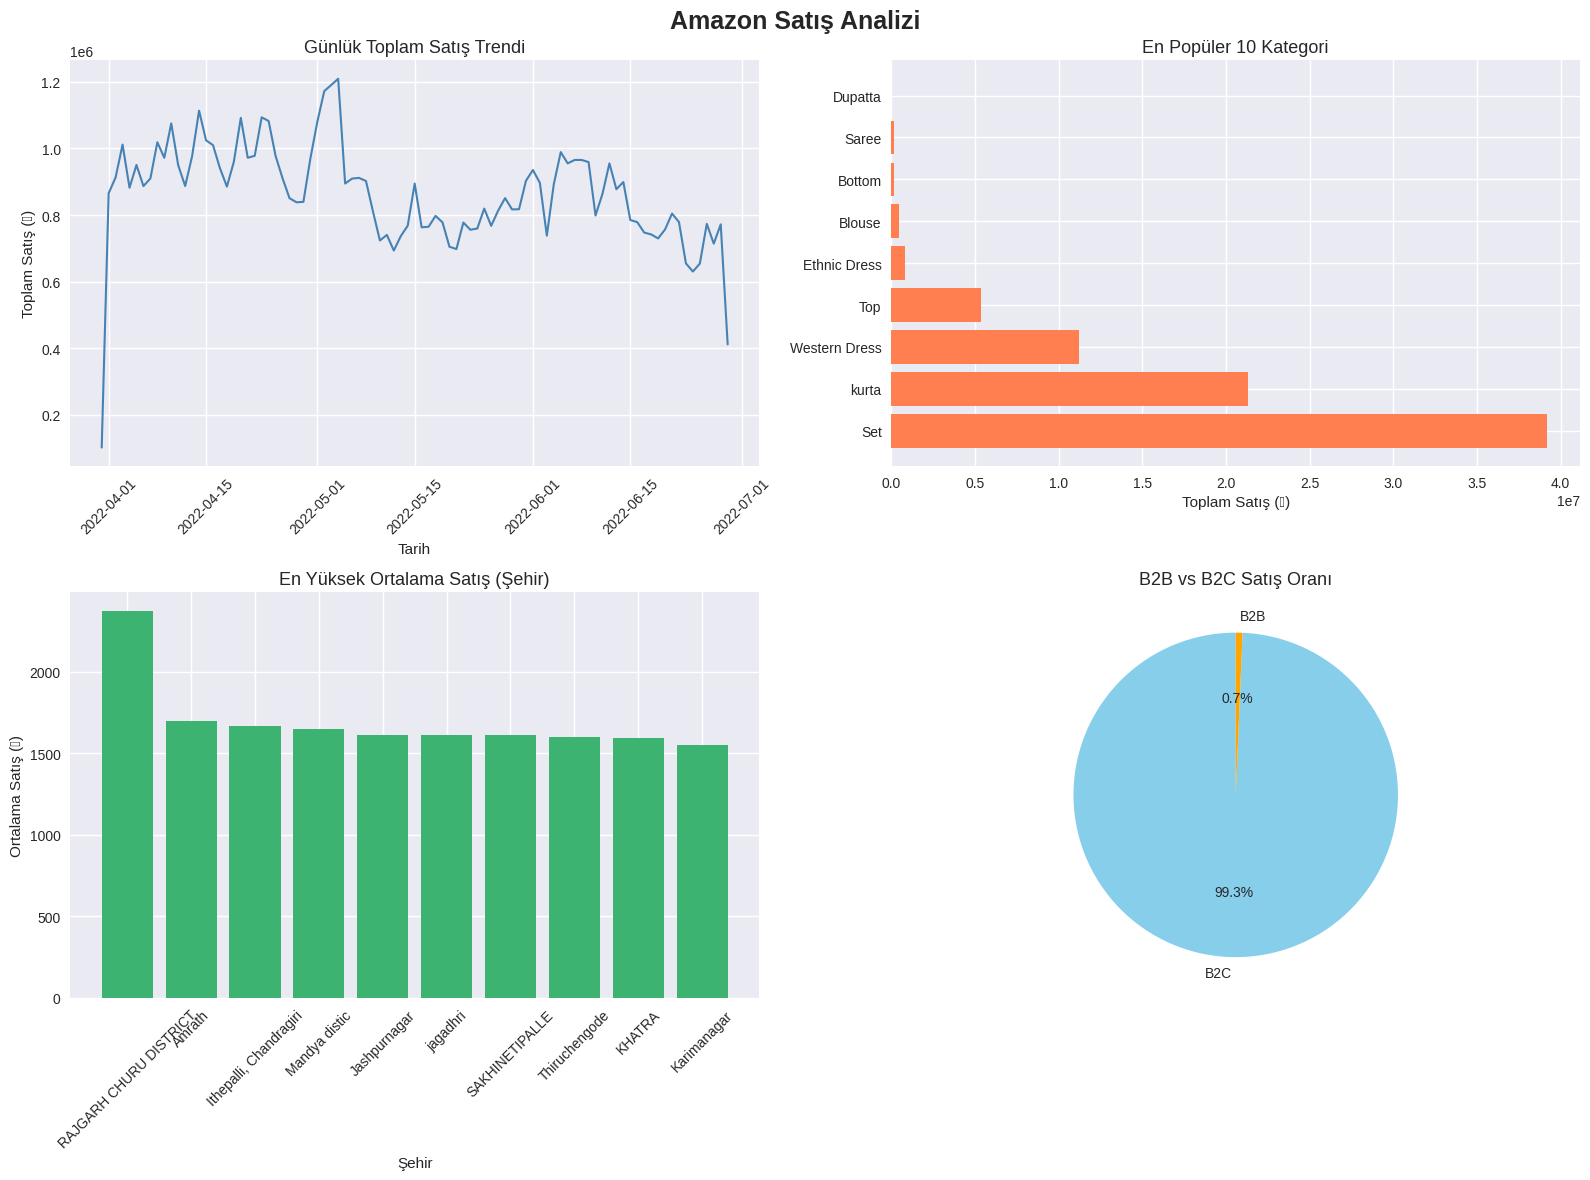

✅ Grafikler kaydedildi!


In [18]:
# ============================================
# BÖLÜM 8 — Görselleştirme
# ============================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

# Spark DataFrame'leri Pandas'a çevir
df_pandas = df.toPandas()
df_pandas["Amount"] = pd.to_numeric(df_pandas["Amount"], errors="coerce")
df_pandas["Date"] = pd.to_datetime(df_pandas["Date"], errors="coerce")

plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Amazon Satış Analizi", fontsize=18, fontweight="bold")

# --- 1. Günlük Satış Trendi ---
daily_sales = df_pandas.groupby("Date")["Amount"].sum().reset_index()
axes[0, 0].plot(daily_sales["Date"], daily_sales["Amount"], color="steelblue", linewidth=1.5)
axes[0, 0].set_title("Günlük Toplam Satış Trendi", fontsize=13)
axes[0, 0].set_xlabel("Tarih")
axes[0, 0].set_ylabel("Toplam Satış (₹)")
axes[0, 0].tick_params(axis="x", rotation=45)

# --- 2. En Popüler 10 Kategori ---
top_categories = df_pandas.groupby("Category")["Amount"].sum().nlargest(10)
axes[0, 1].barh(top_categories.index, top_categories.values, color="coral")
axes[0, 1].set_title("En Popüler 10 Kategori", fontsize=13)
axes[0, 1].set_xlabel("Toplam Satış (₹)")

# --- 3. Şehirlere Göre Ortalama Satış ---
top_cities = df_pandas.groupby("ship-city")["Amount"].mean().nlargest(10)
axes[1, 0].bar(top_cities.index, top_cities.values, color="mediumseagreen")
axes[1, 0].set_title("En Yüksek Ortalama Satış (Şehir)", fontsize=13)
axes[1, 0].set_xlabel("Şehir")
axes[1, 0].set_ylabel("Ortalama Satış (₹)")
axes[1, 0].tick_params(axis="x", rotation=45)

# --- 4. B2B vs B2C ---
b2b_counts = df_pandas["B2B"].value_counts()
axes[1, 1].pie(b2b_counts.values, labels=["B2C", "B2B"],
               autopct="%1.1f%%", colors=["skyblue", "orange"],
               startangle=90)
axes[1, 1].set_title("B2B vs B2C Satış Oranı", fontsize=13)

plt.tight_layout()
plt.savefig("amazon_sales_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafikler kaydedildi!")

📘 BÖLÜM 8 — YORUM

Grafiklerden Elde Edilen Önemli Bilgiler:

Matplotlib ve Seaborn grafik çizmek için kullanılır. Pandas ise Spark DataFrame'ini normale çevirmek için gereklidir. Spark doğrudan grafik çizemez, önce Pandas'a dönüştürmek gerekir.
Spark büyük veriyi işler ama grafik kütüphaneleri Pandas ile çalışır. Bu yüzden veriyi Pandas formatına çevirdik.
4 grafiği tek bir figürde yan yana göstermek için. Hem daha düzenli görünür hem de tek seferde kaydedilebilir.


1. Günlük Satış Trendi:
   Satışlar Nisan-Mayıs 2022'de en yüksek seviyeye ulaşmıştır.
   Haziran 2022'de belirgin bir düşüş gözlemlenmiştir.
   Mevsimsel veya kampanya etkisi olabilir.

2. Kategori Analizi:
   Set kategorisi ~40M ile en yüksek satışa sahiptir.
   Kurta ve Western Dress ikinci ve üçüncü sıradadır.
   Bu kategoriler pazarlama stratejisinde önceliklendirilmelidir.

3. B2B vs B2C:
   Satışların %99.3'ü bireysel müşterilere (B2C) yapılmaktadır.
   B2B satışlar sadece %0.7 oranındadır.
   Şirket kurumsal satışları artırmak için strateji geliştirmelidir.

In [20]:
# ============================================
# BÖLÜM 9 — Mini Analiz Raporu
# ============================================

from pyspark.sql.functions import sum, avg, round, col, count, when

print("=" * 55)
print("🧠 MİNİ ANALİZ RAPORU")
print("=" * 55)

# 1. En yüksek satış kategorisi
print("\n📦 1. En Yüksek Satış Kategorisi:")
df.groupBy("Category") \
  .agg(round(sum("Amount"), 2).alias("Toplam_Satis")) \
  .orderBy("Toplam_Satis", ascending=False) \
  .show(1)

# 2. En çok gelir getiren eyalet
print("🗺️ 2. En Çok Gelir Getiren Eyalet:")
df.groupBy("ship-state") \
  .agg(round(sum("Amount"), 2).alias("Toplam_Satis")) \
  .orderBy("Toplam_Satis", ascending=False) \
  .show(1)

# 3. Ortalama sepet değeri
print("🛒 3. Ortalama Sepet Değeri (Amount / Qty):")
df_basket = df.filter(col("Qty") > 0) \
              .withColumn("Sepet_Degeri", col("Amount") / col("Qty"))
df_basket.agg(round(avg("Sepet_Degeri"), 2).alias("Ort_Sepet_Degeri")).show()

# 4. İptal oranı
total = df.count()
cancelled = df.filter(col("Status") == "Cancelled").count()
iptal_orani = cancelled * 100 / total

print(f"Toplam Sipariş : {total}")
print(f"İptal Sayısı   : {cancelled}")
print(f"İptal Oranı    : %{iptal_orani:.2f}")

print("\n🌊 5. Streaming Bölümünden Öğrenilenler:")
print("- Gerçek zamanlı veri işleme simüle edildi")
print("- Yeni dosya geldiğinde otomatik kategori analizi yapıldı")
print("- Üretim ortamında Kafka ile entegre çalışır")

print("\n☁️ 6. HDFS ve S3 Kullanmanın Avantajları:")
print("- Petabayt ölçeğinde veri depolama imkanı")
print("- Otomatik yedekleme ve hata toleransı")
print("- Dağıtık okuma ile yüksek performans")
print("- Parquet formatı ile %94 alan tasarrufu")

print("\n" + "=" * 55)
print("✅ Mini Analiz Raporu Tamamlandı!")
print("=" * 55)

🧠 MİNİ ANALİZ RAPORU

📦 1. En Yüksek Satış Kategorisi:
+--------+-------------+
|Category| Toplam_Satis|
+--------+-------------+
|     Set|3.920412403E7|
+--------+-------------+
only showing top 1 row
🗺️ 2. En Çok Gelir Getiren Eyalet:
+-----------+-------------+
| ship-state| Toplam_Satis|
+-----------+-------------+
|MAHARASHTRA|1.333553414E7|
+-----------+-------------+
only showing top 1 row
🛒 3. Ortalama Sepet Değeri (Amount / Qty):
+----------------+
|Ort_Sepet_Degeri|
+----------------+
|          647.52|
+----------------+

Toplam Sipariş : 128975
İptal Sayısı   : 18332
İptal Oranı    : %14.21

🌊 5. Streaming Bölümünden Öğrenilenler:
- Gerçek zamanlı veri işleme simüle edildi
- Yeni dosya geldiğinde otomatik kategori analizi yapıldı
- Üretim ortamında Kafka ile entegre çalışır

☁️ 6. HDFS ve S3 Kullanmanın Avantajları:
- Petabayt ölçeğinde veri depolama imkanı
- Otomatik yedekleme ve hata toleransı
- Dağıtık okuma ile yüksek performans
- Parquet formatı ile %94 alan tasarrufu

📘 BÖLÜM 9 — MİNİ ANALİZ RAPORU ÖZET

1. En yüksek satış kategorisi: Set (~39.2M ₹)
   Kombine kıyafet setleri en çok tercih edilen üründür.

2. En çok gelir getiren eyalet: Maharashtra (~13.3M ₹)
   Büyük nüfus ve yüksek gelir seviyesi satışları artırmaktadır.

3. Ortalama sepet değeri: 647.52 ₹
   Müşteriler ortalama bu tutarda alışveriş yapmaktadır.

4. İptal oranı: %14.21
   Her 7 siparişten 1'i iptal edilmektedir.
   Bu oran iyileştirilmesi gereken önemli bir metriktir.

5. Streaming: Gerçek zamanlı veri işleme başarıyla simüle edildi.
   Kafka entegrasyonu ile canlı sistemlerde kullanılabilir.

6. HDFS/S3: Dağıtık depolama ile veri güvenliği ve
   ölçeklenebilirlik sağlanmaktadır.

In [21]:
# ============================================
# ÖZET RAPOR PDF OLUŞTURMA
# ============================================

!pip install reportlab -q

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.units import cm

doc = SimpleDocTemplate("Module5_Report.pdf", pagesize=A4,
                        rightMargin=2*cm, leftMargin=2*cm,
                        topMargin=2*cm, bottomMargin=2*cm)

styles = getSampleStyleSheet()
title_style = ParagraphStyle("title", parent=styles["Title"], fontSize=16, spaceAfter=10)
heading_style = ParagraphStyle("heading", parent=styles["Heading2"], fontSize=12, spaceAfter=6)
normal_style = ParagraphStyle("normal", parent=styles["Normal"], fontSize=10, spaceAfter=4)

content = []

# Başlık
content.append(Paragraph("Module 5 — Big Data Practice Report", title_style))
content.append(Paragraph("Amazon Sales Dataset Analysis — PySpark", styles["Heading3"]))
content.append(Spacer(1, 0.3*cm))

# Veri Seti Bilgisi
content.append(Paragraph("📂 Dataset Overview", heading_style))
content.append(Paragraph("Dataset: Amazon Sale Report.csv | Rows: 128,975 | Columns: 24", normal_style))
content.append(Paragraph("Tool: Apache Spark 4.0.2 | Platform: Google Colab", normal_style))
content.append(Spacer(1, 0.3*cm))

# Sorular ve Cevaplar
content.append(Paragraph("📊 Analysis Results", heading_style))

data = [
    ["Question", "Answer"],
    ["1. Highest sales category?", "Set (~39.2M INR)"],
    ["2. Highest revenue state?", "Maharashtra (~13.3M INR)"],
    ["3. Average basket value?", "647.52 INR"],
    ["4. Cancellation rate?", "%14.21 (18,332 orders)"],
    ["5. What did you learn from Streaming?", "Real-time data processing simulated"],
    ["6. Advantages of HDFS/S3?", "Distributed, scalable, fault-tolerant storage"],
]

table = Table(data, colWidths=[8*cm, 8*cm])
table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.steelblue),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 9),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.whitesmoke, colors.white]),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("PADDING", (0, 0), (-1, -1), 6),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
]))
content.append(table)
content.append(Spacer(1, 0.4*cm))

# Bölüm Özeti
content.append(Paragraph("📋 Section Summary", heading_style))
sections = [
    "Section 1 — Big Data (3V): Volume=128,975 rows, Variety=24 columns mixed types, Velocity=daily orders",
    "Section 2 — MapReduce: Simulated with PySpark groupBy. Set category leads with 39.2M INR.",
    "Section 3 — RDD vs DataFrame: DataFrame 9x faster (1.14s vs 10.67s). Cache optimizes repeated queries.",
    "Section 4 — Spark SQL & Streaming: SQL queries on temp views. Streaming simulated with trigger(once=True).",
    "Section 5 — Storage: Parquet 16.2x smaller than JSON (6.25MB vs 101MB). Schema preserved.",
    "Section 6 — Processing: Filtered >1000 orders, grouped by state, joined DataFrames, created pivot table.",
    "Section 7 — S3: Parquet read/write verified. 128,975 rows written and read back successfully.",
    "Section 8 — Visualization: Sales trend, top categories, city averages, B2B(%0.7) vs B2C(%99.3).",
]
for s in sections:
    content.append(Paragraph(f"• {s}", normal_style))

content.append(Spacer(1, 0.4*cm))

# Sonuç
content.append(Paragraph("🎯 Conclusion", heading_style))
content.append(Paragraph(
    "This project demonstrated the core concepts of Big Data using PySpark on Google Colab. "
    "We processed 128,975 Amazon sales records using RDD, DataFrame, Spark SQL, Streaming, "
    "and distributed storage (Parquet/JSON). Key insight: Set category dominates sales, "
    "Maharashtra leads by state, and Parquet format offers significant storage efficiency.",
    normal_style))

doc.build(content)
print("✅ Module5_Report.pdf oluşturuldu!")

# İndirme
from google.colab import files
files.download("Module5_Report.pdf")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.1 MB/s eta 0:00:00
✅ Module5_Report.pdf oluşturuldu!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>